In [17]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [18]:
# connect to existing database - created from parsing scripts
conn = sqlite3.connect('unitrans.db')

# view the predictions table
predictions = pd.read_sql_query("SELECT * FROM predictions", conn)

predictions


,route_title,route_tag,stop_title,stop_tag,file_time,predicted_arrival_at,direction,mins,secs,is_departure,affected_by_layover,vehicle,block,trip_tag,day_name,service_class
0,A,A,Memorial Union & Main Island (SB),22273,2026-02-23 11:05:00,2026-02-23 12:09:00,outbound to el cemonte,64,3894,true,true,LMU_4019,29,A_11_outbound_1210,Monday,MoTuTh
1,G,G,Memorial Union & Main Island (SB),22273,2026-02-23 11:05:00,2026-02-23 11:24:00,outbound to n sycamore,19,1194,true,true,LMU_4088,24,G_11_outbound_1125,Monday,MoTuTh
2,M,M,Memorial Union & Main Island (SB),22273,2026-02-23 11:05:00,2026-02-23 11:24:00,outbound to drew,19,1194,true,true,LMU_4090,22,M_11_outbound_1125,Monday,MoTuTh
3,E,E,Memorial Union & East Island (SB),22274,2026-02-23 11:05:00,2026-02-23 11:29:00,outbound to j st,24,1494,true,true,LMU_4084,23,E_11_outbound_1130,Monday,MoTuTh
4,F,F,Memorial Union & East Island (SB),22274,2026-02-23 11:05:00,2026-02-23 11:24:00,outbound to f st,19,1194,true,true,LMU_4087,25,F_11_outbound_1125,Monday,MoTuTh
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15452,U,U,Memorial Union & East Island (SB),22274,2026-03-01 18:25:00,2026-03-01 18:34:00,outbound to west village via russell blvd,9,596,true,true,LMU_4011,65,U_20_outbound_1835,Sunday,Sunday
15453,M,M,Memorial Union & Main Island (SB),22273,2026-03-01 18:30:00,2026-03-01 18:34:00,outbound to drew,4,296,true,true,LMU_4020,64,M_20_outbound_1835,Sunday,Sunday
15454,U,U,Memorial Union & East Island (SB),22274,2026-03-01 18:30:00,2026-03-01 18:35:00,outbound to west village via russell blvd,5,339,true,true,LMU_4011,65,U_20_outbound_1835,Sunday,Sunday
15455,M,M,Memorial Union & Main Island (SB),22273,2026-03-01 18:35:00,2026-03-01 18:35:00,outbound to drew,0,40,true,true,LMU_4020,64,M_20_outbound_1835,Sunday,Sunday


In [19]:
# view the schedules table
schedules = pd.read_sql_query("SELECT * FROM schedules", conn)

schedules

#route_tag	service_class	direction	block_id	stopTag	stop_name	arrival_time	epoch	arrival_dt

,route_tag,service_class,direction,block_id,stopTag,stop_name,arrival_time_str,arrival_time
0,A,Friday,inbound to ucd mu,29,22062,El Cemonte Ave & Glide Drive (SB),07:15:00,07:15:00
1,A,Friday,inbound to ucd mu,29,22065,Alhambra Drive & Mace Blvd (WB),07:20:00,07:20:00
2,A,Friday,inbound to ucd mu,29,22072,5th St & Cantrill/Greystone (WB),07:25:00,07:25:00
3,A,Friday,inbound to ucd mu,29,22012,H St & 2nd St / Amtrak (SB),07:31:00,07:31:00
4,A,Friday,inbound to ucd mu,29,22273_ar,Memorial Union & Main Island (SB),07:50:00,07:50:00
...,...,...,...,...,...,...,...,...
14693,Z,Wednesday,outbound to target,6,22258,Silo Terminal & Haring Hall (WB),22:10:00,22:10:00
14694,Z,Wednesday,outbound to target,6,22011,Alhambra Drive & Mace Blvd (WB),22:17:00,22:17:00
14695,Z,Wednesday,outbound to target,6,22073,5th St & Cantrill/Greystone (WB),22:24:00,22:24:00
14696,Z,Wednesday,outbound to target,6,22066,H St & 2nd St / Amtrak (SB),22:28:00,22:28:00


In [20]:
# merge the prediction and schedules tables together
# biggest issue was with the time conversions - needed to use julian time to bridge the gap
merged_table = pd.read_sql("""
SELECT
    p.rowid AS pred_id,
    p.predicted_arrival_at,
    p.route_tag,
    -- Calculate the lateness (mins) via Julian Day math
    (
        julianday(p.predicted_arrival_at) - 
        julianday(date(p.predicted_arrival_at) || ' ' || s.arrival_time_str)
    ) * 1440 AS lateness_min
FROM predictions AS p
FULL JOIN schedules AS s
    -- fully group unique route combinations
    ON p.route_tag = s.route_tag
    AND p.stop_tag = s.stopTag
    AND p.block = s.block_id
    AND p.direction = s.direction
    AND p.service_class = s.service_class
WHERE p.predicted_arrival_at IS NOT NULL
""", conn)

conn.close()


In [21]:
merged_table

,pred_id,predicted_arrival_at,route_tag,lateness_min
0,1,2026-02-23 12:09:00,A,314.0
1,1,2026-02-23 12:09:00,A,254.0
2,1,2026-02-23 12:09:00,A,189.0
3,1,2026-02-23 12:09:00,A,129.0
4,1,2026-02-23 12:09:00,A,69.0
...,...,...,...,...
228929,15457,2026-03-01 18:36:00,U,241.0
228930,15457,2026-03-01 18:36:00,U,181.0
228931,15457,2026-03-01 18:36:00,U,121.0
228932,15457,2026-03-01 18:36:00,U,61.0


In [22]:
# since merged on the blocks, we sort by the individual predictions
# keep the ones closest to the sheduled time then drop the rest
merged_table['abs_lateness'] = merged_table['lateness_min'].abs()
merged_table = merged_table.sort_values(['pred_id', 'abs_lateness']).drop_duplicates(subset=['pred_id'])

In [23]:
merged_table[merged_table['route_tag'] == 'P']

,pred_id,predicted_arrival_at,route_tag,lateness_min,abs_lateness
260,17,2026-02-23 11:29:00,P,-1.0,1.0
537,35,2026-02-23 11:29:00,P,-1.0,1.0
814,53,2026-02-23 12:09:00,P,-1.0,1.0
1096,71,2026-02-23 12:09:00,P,-1.0,1.0
1386,89,2026-02-23 12:09:00,P,-1.0,1.0
...,...,...,...,...,...
228565,15421,2026-03-01 18:09:00,P,-1.0,1.0
228637,15428,2026-03-01 18:12:00,P,2.0,2.0
228709,15435,2026-03-01 18:14:00,P,4.0,4.0
228781,15442,2026-03-01 18:14:00,P,4.0,4.0


In [24]:
# prepare the columns for the heatmap
merged_table['predicted_arrival_at'] = pd.to_datetime(merged_table['predicted_arrival_at'])
merged_table['day'] = merged_table['predicted_arrival_at'].dt.date
merged_table['hour'] = merged_table['predicted_arrival_at'].dt.hour       

In [26]:
merged_table[merged_table['route_tag'] == 'C'].sort_values('lateness_min', ascending=False)

,pred_id,predicted_arrival_at,route_tag,lateness_min,abs_lateness,day,hour
111072,7182,2026-02-25 17:03:00,C,23.000000,23.000000,2026-02-25,17
117679,7599,2026-02-25 19:02:00,C,22.000000,22.000000,2026-02-25,19
114515,7398,2026-02-25 18:02:00,C,22.000000,22.000000,2026-02-25,18
110801,7164,2026-02-25 17:00:00,C,20.000000,20.000000,2026-02-25,17
78481,5091,2026-02-24 22:00:00,C,19.999999,19.999999,2026-02-24,22
...,...,...,...,...,...,...,...
207089,13579,2026-02-27 18:39:00,C,-1.000001,1.000001,2026-02-27,18
207363,13597,2026-02-27 18:39:00,C,-1.000001,1.000001,2026-02-27,18
207856,13629,2026-02-27 18:39:00,C,-1.000001,1.000001,2026-02-27,18
208110,13646,2026-02-27 18:39:00,C,-1.000001,1.000001,2026-02-27,18


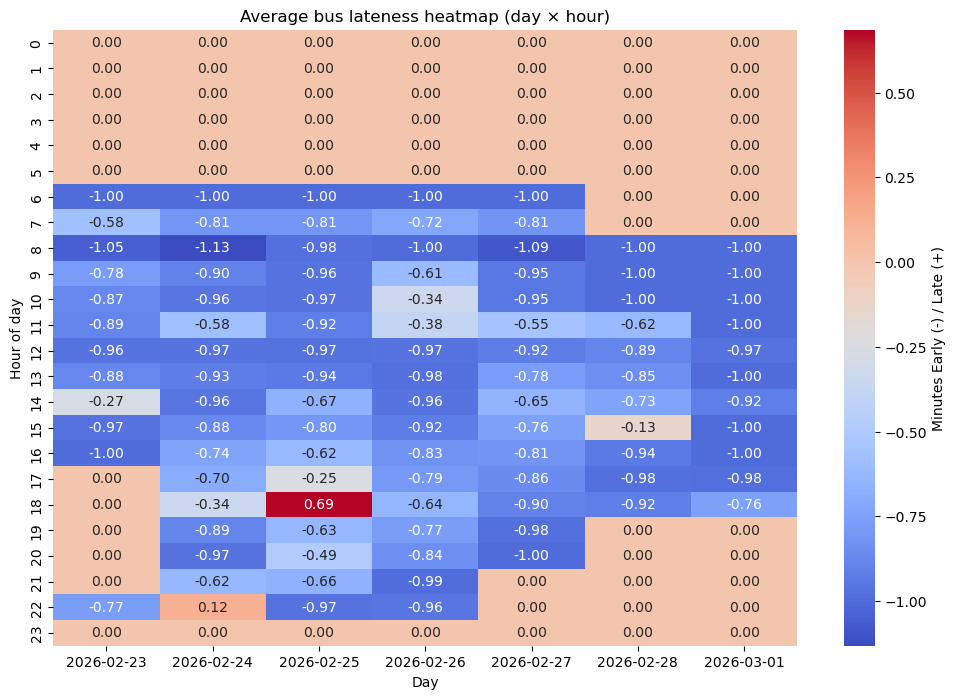

In [25]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

heat = (
    merged_table.groupby(["hour", "day"])["lateness_min"]
    .mean()
    .unstack("day")
)

# increase figsize
plt.figure(figsize=(12, 8))

# define to list all 24hrs 
heat = heat.reindex(range(24))

# fill empty hours with 0
heat = heat.fillna(0)

sns.heatmap(heat,
            annot=True,
            fmt=".2f",
            cbar_kws={'label': 'Minutes Early (-) / Late (+)'},
            cmap='coolwarm'
)

plt.xlabel("Day")
plt.ylabel("Hour of day")
plt.title("Average bus lateness heatmap (day × hour)")
plt.show()

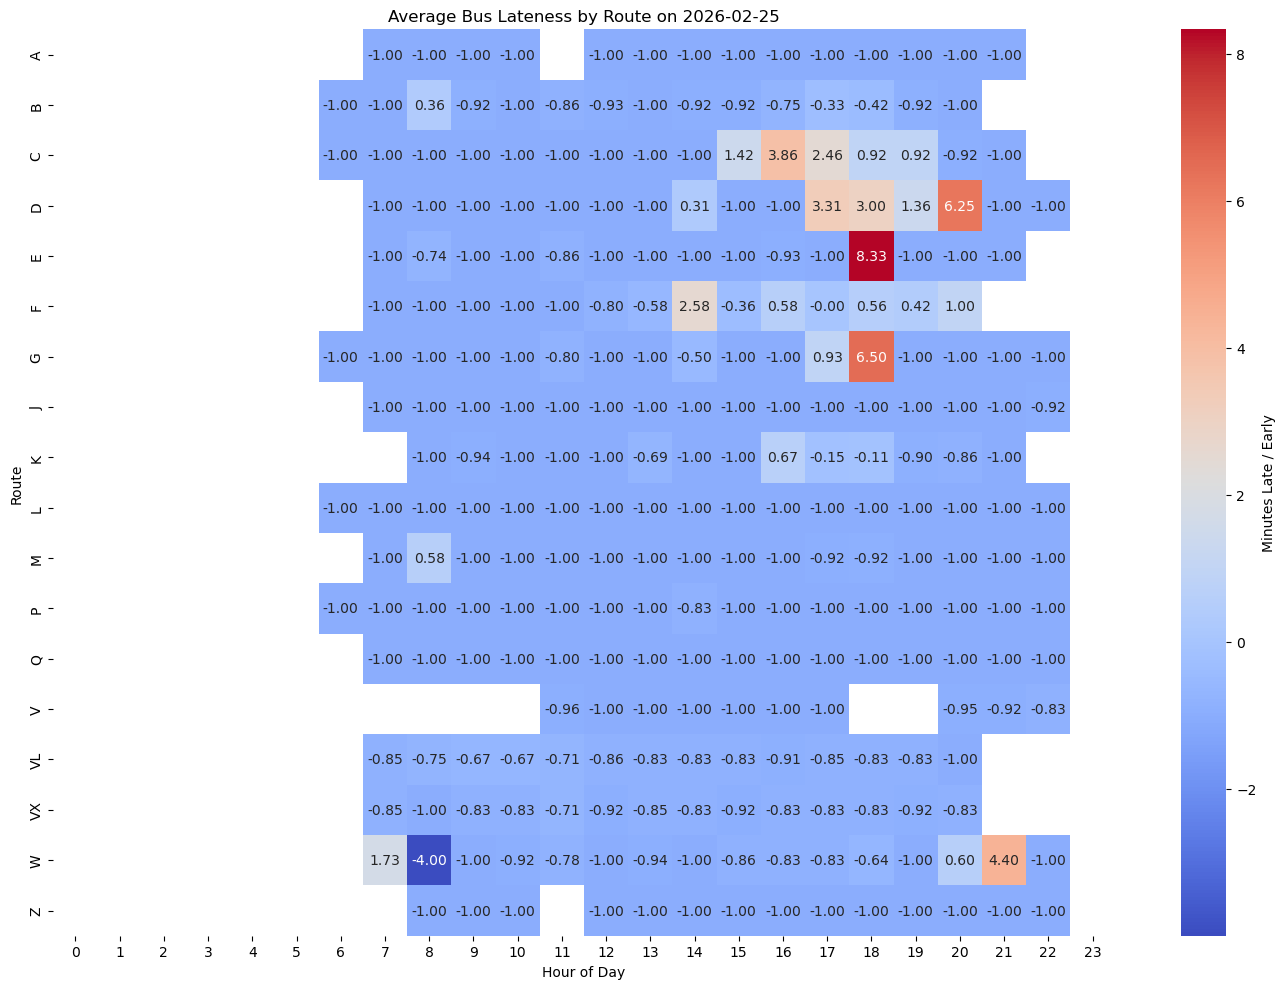

In [10]:
# heatmap of individual day
# ex: Wednesday, Feb 25, 2026
# ensure target date matches format
target_date = pd.to_datetime('2026-02-25').date()

# filter the dataframe to only include this single day
df_day = merged_table[merged_table['day'] == target_date].copy()

# group by route and rour instead of day and hour
heat_route = (
    df_day.groupby(["route_tag", "hour"])["lateness_min"]
    .mean()
    .unstack("hour")  # This pushes the 24 hours across the cols
)

# ensure all 24 hours shown
heat_route = heat_route.reindex(columns=range(24))

# plot
plt.figure(figsize=(14, 10))

sns.heatmap(
    heat_route, 
    annot=True,      
    fmt=".2f",       
    cbar_kws={'label': 'Minutes Late / Early'},
    cmap='coolwarm'
)

plt.xlabel("Hour of Day")
plt.ylabel("Route")
plt.title(f"Average Bus Lateness by Route on {target_date}")
plt.tight_layout()
plt.show()

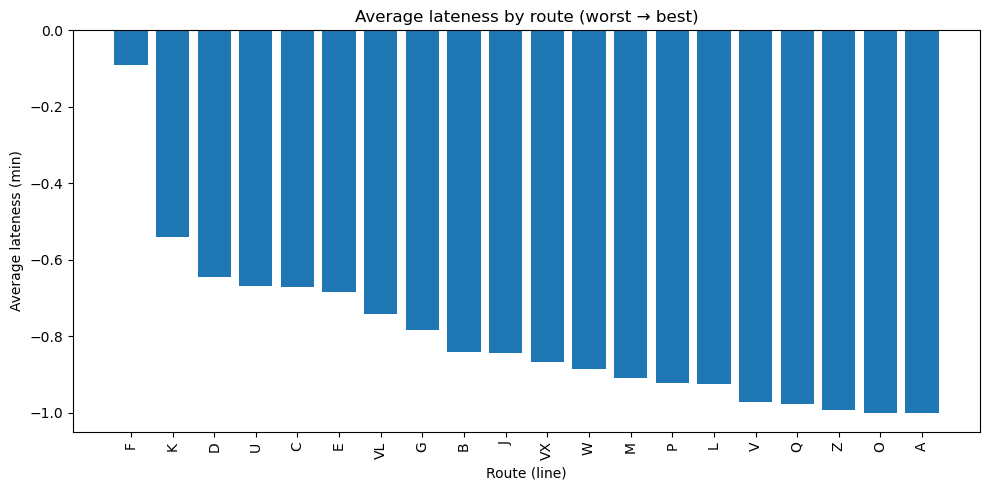

In [11]:
route_avg = (merged_table.groupby("route_tag")["lateness_min"]
             .mean()
             .sort_values(ascending=False))

plt.figure(figsize=(10, 5))
plt.bar(route_avg.index.astype(str), route_avg.values)
plt.xticks(rotation=90)
plt.xlabel("Route (line)")
plt.ylabel("Average lateness (min)")
plt.title("Average lateness by route (worst → best)")
plt.tight_layout()
plt.show()

#the negative values basially stating that it is earlier



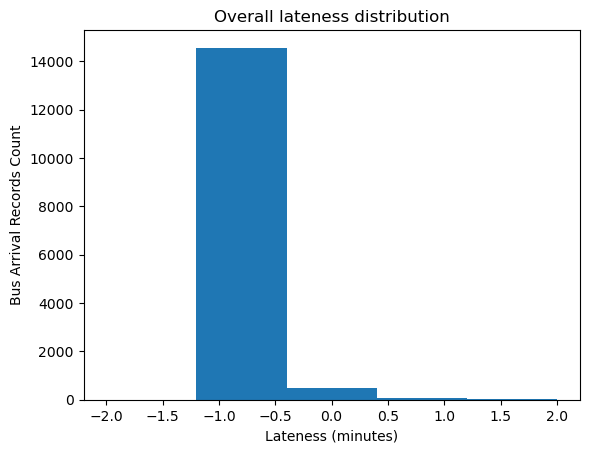

In [12]:
plt.hist(merged_table["lateness_min"], range=(-2,2), bins=5)
plt.xlabel("Lateness (minutes)")
plt.ylabel("Bus Arrival Records Count")
plt.title("Overall lateness distribution")
plt.show()

#number of observations in the lateness range

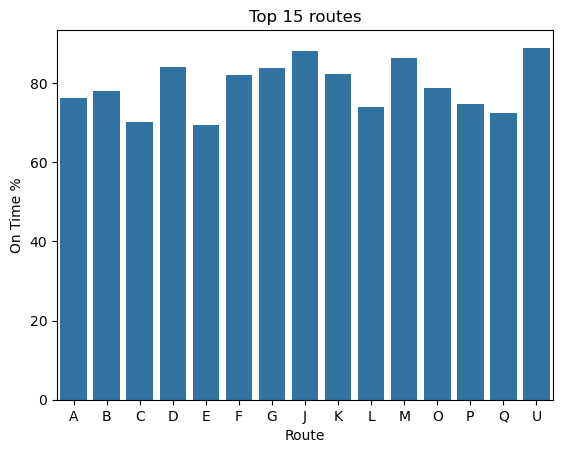

In [13]:
tmp = merged_table.copy()
tmp["on_time"] = tmp["lateness_min"].between(-1, 5)



otp = (merged_table.assign(on_time=merged_table["lateness_min"].between(-1, 5))
         .groupby("route_tag")["on_time"]
         .mean()
         .mul(100)
         .reset_index(name="on_time_pct")
       )
#doing the .mean() for -1 to 5 mins, then doing the mean(get a percentage) then get to multiply

sns.barplot(data=otp.head(15), x="route_tag", y="on_time_pct")
plt.xlabel("Route")
plt.ylabel("On Time %")
plt.title("Top 15 routes")
plt.show()

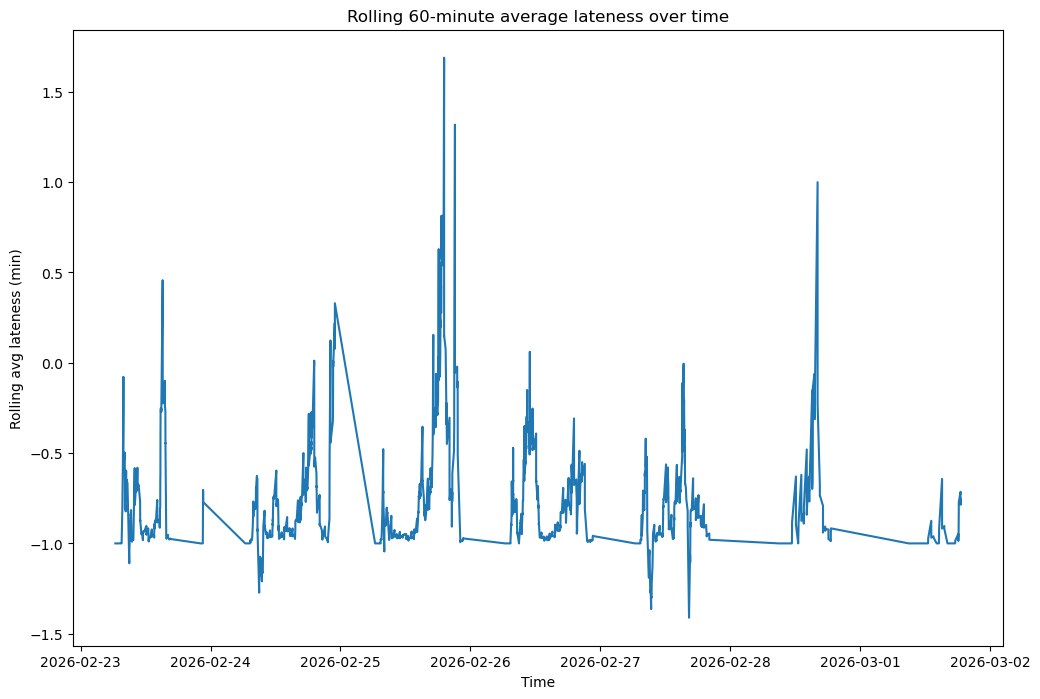

In [14]:
sub = merged_table.sort_values("predicted_arrival_at").copy()
sub = sub.set_index("predicted_arrival_at")

roll = sub["lateness_min"].rolling("60min").mean()  
# average over 60 minutes
plt.figure(figsize=(12, 8))

plt.plot(roll.index, roll.values)
plt.xlabel("Time")
plt.ylabel("Rolling avg lateness (min)")
plt.title("Rolling 60-minute average lateness over time")
plt.show()

#Instead of plotting every single lateness point (noisy),

#it computes the average lateness in the last 60 minutes at each time point (rolling window).

#That answers: “Over the day, when was the system generally running late/early?”

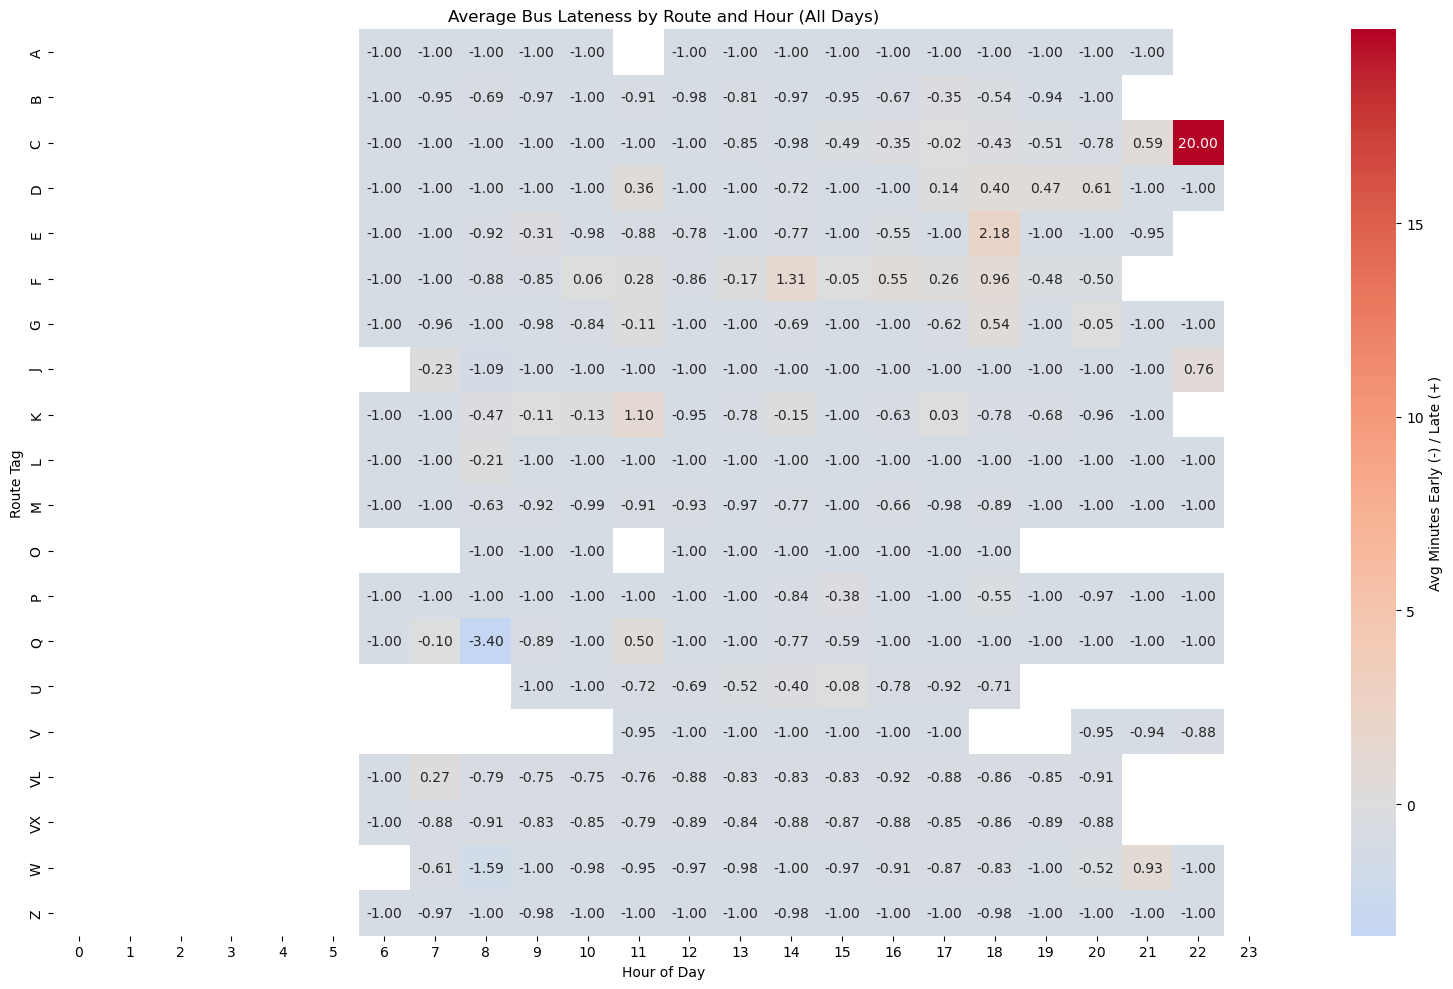

In [ ]:

# group by route and hour, then calculate the mean lateness
# averages the lateness for every occurrence of that route at that hour across all days
heat_route_all_days = (
    merged_table.groupby(["route_tag", "hour"])["lateness_min"]
    .mean()
    .unstack("hour")  
)

# ensure all 24 hours (0-23) are represented in the columns
heat_route_all_days = heat_route_all_days.reindex(columns=range(24))

# create the heatmap
plt.figure(figsize=(16, 10))

sns.heatmap(
    heat_route_all_days, 
    annot=True,      
    fmt=".2f",       
    cbar_kws={'label': 'Avg Minutes Early (-) / Late (+)'},
    cmap='coolwarm', # blue = early, red = late
    center=0      
)

plt.xlabel("Hour of Day")
plt.ylabel("Route Tag")
plt.title("Average Bus Lateness by Route and Hour (All Days)")
plt.tight_layout()


plt.savefig('route_hour_avg_heatmap.png')
plt.show()